In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [16]:
df=pd.read_csv("flood dataset.csv")


In [17]:
new_df=df.drop(['A', 'Period', 'LATITUDE' , 'LONGITUDE','Station Number'], axis=1)


In [18]:
new_df.head(6)

,Station Names,YEAR,Month,Max Temp,Min Temp,Rainfall,Relative Humidity,Wind Speed,Cloud Coverage,Bright Sunshine,X_COR,Y_COR,ALT
0,Barisal,1949,1,29.4,12.3,0.0,68.0,0.453704,0.6,7.831915,536809.8,510151.9,4
1,Barisal,1950,1,30.0,14.1,0.0,77.0,0.453704,0.8,7.831915,536809.8,510151.9,4
2,Barisal,1951,1,28.2,12.3,0.0,77.0,0.453704,0.6,7.831915,536809.8,510151.9,4
3,Barisal,1952,1,26.6,12.3,2.0,77.0,0.453704,1.0,7.831915,536809.8,510151.9,4
4,Barisal,1953,1,30.0,13.3,10.0,75.0,0.453704,1.6,7.831915,536809.8,510151.9,4
5,Barisal,1954,1,27.8,12.7,0.0,72.0,0.453704,0.5,7.831915,536809.8,510151.9,4


In [20]:
new_df.rename(columns={'Station Names': 'District'}, inplace=True)


In [21]:
new_df['District'].value_counts()

,count
District,
Khulna,792
Dinajpur,792
Bogra,792
Srimangal,792
Satkhira,792
Mymensingh,792
Jessore,792
Comilla,792
Cox's Bazar,792


In [22]:
new_df.tail(5)

,District,YEAR,Month,Max Temp,Min Temp,Rainfall,Relative Humidity,Wind Speed,Cloud Coverage,Bright Sunshine,X_COR,Y_COR,ALT
21115,Teknaf,2009,12,30.3,16.5,0.0,72.0,2.8,0.9,8.7,734765.4,308914.1,4
21116,Teknaf,2010,12,31.7,16.7,193.0,79.0,2.4,1.4,5.5,734765.4,308914.1,4
21117,Teknaf,2011,12,31.5,16.4,0.0,73.0,0.0,1.5,7.4,734765.4,308914.1,4
21118,Teknaf,2012,12,30.0,15.8,0.0,70.0,1.8,0.2,9.0,734765.4,308914.1,4
21119,Teknaf,2013,12,29.9,16.5,0.0,72.0,3.0,0.9,8.1,734765.4,308914.1,4


In [23]:
Train_df = new_df[~new_df['District'].isin(['Ishurdi', 'Maijdee Court'])]

In [24]:
Train_df['District'].value_counts()

,count
District,
Khulna,792
Dinajpur,792
Bogra,792
Srimangal,792
Satkhira,792
Mymensingh,792
Jessore,792
Comilla,792
Cox's Bazar,792


In [28]:
Train_df.drop(['District','YEAR'], axis=1, inplace=True)

In [29]:
Train_df

,Month,Max Temp,Min Temp,Rainfall,Relative Humidity,Wind Speed,Cloud Coverage,Bright Sunshine,X_COR,Y_COR,ALT
0,1,29.4,12.3,0.0,68.0,0.453704,0.6,7.831915,536809.8,510151.9,4
1,1,30.0,14.1,0.0,77.0,0.453704,0.8,7.831915,536809.8,510151.9,4
2,1,28.2,12.3,0.0,77.0,0.453704,0.6,7.831915,536809.8,510151.9,4
3,1,26.6,12.3,2.0,77.0,0.453704,1.0,7.831915,536809.8,510151.9,4
4,1,30.0,13.3,10.0,75.0,0.453704,1.6,7.831915,536809.8,510151.9,4
...,...,...,...,...,...,...,...,...,...,...,...
21115,12,30.3,16.5,0.0,72.0,2.800000,0.9,8.700000,734765.4,308914.1,4
21116,12,31.7,16.7,193.0,79.0,2.400000,1.4,5.500000,734765.4,308914.1,4
21117,12,31.5,16.4,0.0,73.0,0.000000,1.5,7.400000,734765.4,308914.1,4
21118,12,30.0,15.8,0.0,70.0,1.800000,0.2,9.000000,734765.4,308914.1,4


In [30]:
Train_df.corr()['Rainfall']

,Rainfall
Month,0.131890
Max Temp,0.263545
Min Temp,0.595328
Rainfall,1.000000
Relative Humidity,0.591652
Wind Speed,0.315075
Cloud Coverage,0.766719
Bright Sunshine,-0.668863
X_COR,0.163306
Y_COR,-0.060786


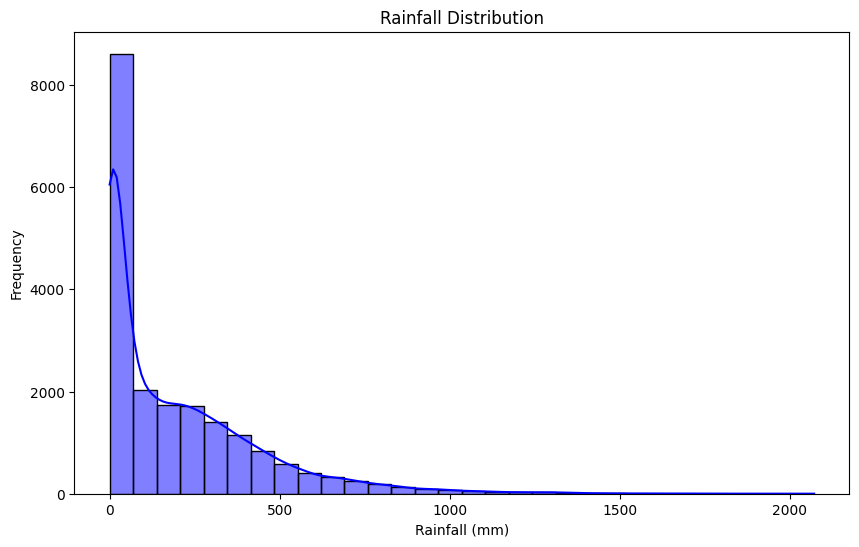

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of rainfall
plt.figure(figsize=(10, 6))
sns.histplot(Train_df['Rainfall'], kde=True, bins=30, color='blue')
plt.title('Rainfall Distribution')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.show()

In [32]:
# Calculate percentiles to check for thresholds
threshold_90 = Train_df['Rainfall'].quantile(0.90)  # 90th percentile
threshold_95 = Train_df['Rainfall'].quantile(0.95)  # 95th percentile
threshold_99 = Train_df['Rainfall'].quantile(0.99)  # 99th percentile

print(f"90th percentile: {threshold_90}")
print(f"95th percentile: {threshold_95}")
print(f"99th percentile: {threshold_99}")


90th percentile: 512.0
95th percentile: 678.0
99th percentile: 1038.0


In [33]:
def label_flash_flood(row, threshold=512):

    return 1 if row['Rainfall'] >= threshold else 0

# Apply the function to create the flood probability column
Train_df['Flood_Probability'] = Train_df.apply(label_flash_flood, axis=1, threshold=threshold_90)


In [34]:
Train_df['Flood_Probability'].value_counts()

,count
Flood_Probability,
0,17745
1,1983


In [35]:
columns_to_scale=['Max Temp', 'Min Temp', 'Rainfall', 'Relative Humidity',
                    'Wind Speed', 'Cloud Coverage', 'Bright Sunshine', 'X_COR', 'Y_COR', 'ALT']


In [36]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
Train_df[columns_to_scale]=scaler.fit_transform(Train_df[columns_to_scale])

In [37]:
# Apply cyclic encoding
Train_df['month_sin'] = np.sin(2 * np.pi * Train_df['Month'] / 12)
Train_df['month_cos'] = np.cos(2 * np.pi * Train_df['Month'] / 12)
Train_df.drop(columns=['Month'], inplace=True)

In [38]:
Train_df.head()

,Max Temp,Min Temp,Rainfall,Relative Humidity,Wind Speed,Cloud Coverage,Bright Sunshine,X_COR,Y_COR,ALT,Flood_Probability,month_sin,month_cos
0,0.349776,0.278539,0.000000,0.539683,0.040509,0.075949,0.711992,0.730587,0.603857,0.063492,0,0.5,0.866025
1,0.376682,0.360731,0.000000,0.682540,0.040509,0.101266,0.711992,0.730587,0.603857,0.063492,0,0.5,0.866025
2,0.295964,0.278539,0.000000,0.682540,0.040509,0.075949,0.711992,0.730587,0.603857,0.063492,0,0.5,0.866025
3,0.224215,0.278539,0.000965,0.682540,0.040509,0.126582,0.711992,0.730587,0.603857,0.063492,0,0.5,0.866025
4,0.376682,0.324201,0.004826,0.650794,0.040509,0.202532,0.711992,0.730587,0.603857,0.063492,0,0.5,0.866025


In [39]:
features=Train_df.drop(['Flood_Probability'],axis=1)
target=Train_df['Flood_Probability']
features = np.array(features)
target = np.array(target)

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features,target, test_size=0.3, stratify=target, random_state=42)

In [41]:
print(y_train.shape)
print(y_test.shape)
print(X_train.shape)
print(X_test.shape)

(13809,)
(5919,)
(13809, 12)
(5919, 12)


In [42]:
X_train_1 = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_1 = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [43]:
from sklearn.utils import class_weight
class_wt = class_weight.compute_class_weight(class_weight='balanced',
                                             classes = np.unique(y_train),
                                             y = y_train)
class_wt = dict(enumerate(class_wt))

In [44]:
print(class_wt)

{0: 0.5558731181064327, 1: 4.974423631123919}


In [45]:
import tensorflow as tf
import keras
from keras.layers import Input, Dense, MultiHeadAttention, LSTM, GRU, Conv1D, LayerNormalization, BatchNormalization, Dropout, Bidirectional
from keras.models import Model
from keras.regularizers import l2
from keras.optimizers import Adam
from keras import callbacks
from keras.callbacks import EarlyStopping

In [47]:
inputs = Input(shape=(X_train.shape[1], 1))

x = Dense(32)(inputs)

x = LSTM(128, return_sequences=True)(x)
x = Dropout(0.2)(x)
x = LayerNormalization(epsilon=1e-5)(x)

x = LSTM(128)(x)
x = Dropout(0.2)(x)
x = LayerNormalization(epsilon=1e-5)(x)

x = Dense(64, activation = 'relu')(x)
outputs = Dense(1, activation = 'sigmoid')(x)

model = Model(inputs, outputs)
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [48]:
history = model.fit(X_train_1, y_train, validation_data = (X_test_1, y_test), epochs = 16, batch_size = 64,
                     callbacks = [EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights=True)])

Epoch 1/16
216/216 ━━━━━━━━━━━━━━━━━━━━ 25s 83ms/step - accuracy: 0.8867 - loss: 0.2749 - val_accuracy: 0.8995 - val_loss: 0.2290
Epoch 2/16
216/216 ━━━━━━━━━━━━━━━━━━━━ 17s 80ms/step - accuracy: 0.9013 - loss: 0.2314 - val_accuracy: 0.8995 - val_loss: 0.2238
Epoch 3/16
216/216 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.9024 - loss: 0.2186 - val_accuracy: 0.9326 - val_loss: 0.1708
Epoch 4/16
216/216 ━━━━━━━━━━━━━━━━━━━━ 18s 83ms/step - accuracy: 0.9173 - loss: 0.1995 - val_accuracy: 0.9468 - val_loss: 0.1495
Epoch 5/16
216/216 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - accuracy: 0.9399 - loss: 0.1489 - val_accuracy: 0.9640 - val_loss: 0.0875
Epoch 6/16
216/216 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - accuracy: 0.9621 - loss: 0.0928 - val_accuracy: 0.9662 - val_loss: 0.1129
Epoch 7/16
216/216 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - accuracy: 0.9820 - loss: 0.0459 - val_accuracy: 0.9777 - val_loss: 0.0383
Epoch 8/16
216/216 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.9857 - loss: 0.0333 - 

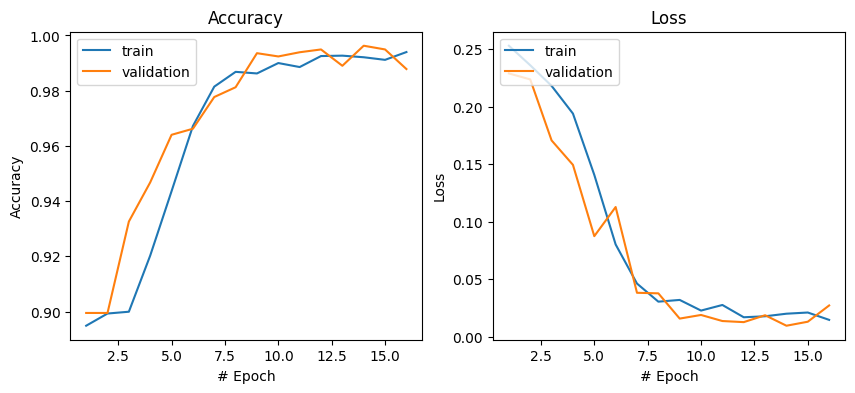

In [49]:
import matplotlib.pyplot as plt

# Assuming `history` contains your training history
epochs = len(history.history['accuracy'])

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# Accuracy
ax[0].plot(range(1, epochs + 1), history.history['accuracy'], label='train')
ax[0].plot(range(1, epochs + 1), history.history['val_accuracy'], label='validation')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('# Epoch')
ax[0].legend(loc='upper left')
ax[0].set_title('Accuracy')

# Loss
ax[1].plot(range(1, epochs + 1), history.history['loss'], label='train')
ax[1].plot(range(1, epochs + 1), history.history['val_loss'], label='validation')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('# Epoch')
ax[1].legend(loc='upper left')
ax[1].set_title('Loss')
plt.show()

In [54]:
test_result = model.evaluate(X_test_1, y_test, batch_size=64)

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9964 - loss: 0.0090


In [55]:
from sklearn.metrics import classification_report, confusion_matrix

In [56]:
y_pred_test = model.predict(X_test_1, batch_size = 64)
y_pred = (y_pred_test >= 0.5).astype(int)
print(f"Classification_report:\n{classification_report(y_test, y_pred)}")

93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step
Classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5324
           1       0.98      0.98      0.98       595

    accuracy                           1.00      5919
   macro avg       0.99      0.99      0.99      5919
weighted avg       1.00      1.00      1.00      5919



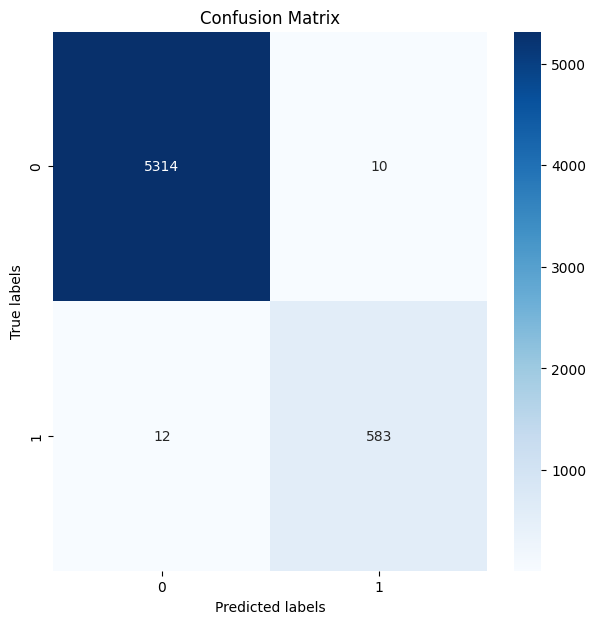

In [57]:
classes = ['0', '1']
cnf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 7))
sns.heatmap(cnf_matrix, annot=True, fmt='d', cmap=plt.cm.Blues,
            xticklabels=classes, yticklabels=classes)

plt.title('Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()